In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWFyY2UvTmV4dGNsb3VkL01hdGVtw6F0aWNhIEQvQXB1bnRlIFF1YXJ0byAyMDI1L2NoYXB0ZXJz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/usr/lib/python3.12/importlib/_bootstrap.py": 1769115462.0, "/usr/lib/python3.12/importlib/_bootstrap_external.py": 1769115462.0, "/usr/lib/python3.12/zipimport.py": 1769115462.0, "/usr/lib/python3.12/codecs.py": 1769115462.0, "/usr/lib/python3.12/encodings/aliases.py": 1769115462.0, "/usr/lib/python3.12/encodings/__init__.py": 1769115462.0, "/usr/lib/python3.12/encodings/utf_8.py": 1769115462.0, "/usr/lib/python3.12/abc.py": 1769115462.0, "/usr/lib/python3.12/io.py": 1769115462.0, "/usr/lib/python3.12/stat.py": 1769115462.0, "/usr/lib/python3.12/_collections_abc.py": 1769115462.0, "/usr/lib/python3.12/genericpath.py": 1769115462.0, "/usr/lib/python3.12/posixpath.py": 1769115462.0, "/usr/lib/python3.12/os.py": 1769115462.0, "/usr/lib/python3.12/_sitebuiltins.py": 1769115462.0, "/usr/lib/python3/dist-packages/_distutils_hack/__init__.py": 1692360458.0, "/usr/lib/python3.12/types.py": 1769115462.0, "/usr/lib/python3.12/warnings.py": 1769115462.0, "/usr/lib/python3.12/importlib/__init__

In [2]:
import numpy as np
np.cos(1)

0.5403023058681398

In [3]:
#| eval: false
help(np.cos)

In [4]:
#| error: true
cos(1)  # Esto dará error

NameError: name 'cos' is not defined

In [5]:
import math
math.cos(1)

0.5403023058681398

In [6]:
import numpy as np
import math

# Con math (solo acepta un número)
x = 1.5
resultado_math = math.cos(x)
print(f"math.cos({x}) = {resultado_math}")

# Con numpy (acepta arrays)
x_array = np.array([0, np.pi/4, np.pi/2, np.pi])
resultado_numpy = np.cos(x_array)
print(f"np.cos(array) = {resultado_numpy}")

math.cos(1.5) = 0.0707372016677029
np.cos(array) = [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -1.00000000e+00]


In [7]:
# Matplotlib para gráficos
import matplotlib.pyplot as plt

# SciPy para métodos científicos avanzados
import scipy

In [8]:
# Suma
2 + 3

5

In [9]:
# Resta
10 - 4

6

In [10]:
# Multiplicación
5 * 6

30

In [11]:
# División
20 / 4

5.0

In [12]:
# División entera (cociente)
20 // 3

6

In [13]:
# Módulo (resto)
20 % 3

2

In [14]:
# Potencia
2**8

256

In [15]:
# Sin paréntesis
2 + 3 * 4

14

In [16]:
# Con paréntesis
(2 + 3) * 4

20

In [17]:
import numpy as np

# Funciones trigonométricas
print(f"sen(π/2) = {np.sin(np.pi/2)}")
print(f"cos(π) = {np.cos(np.pi)}")
print(f"tan(π/4) = {np.tan(np.pi/4)}")

sen(π/2) = 1.0
cos(π) = -1.0
tan(π/4) = 0.9999999999999999


In [18]:
# Exponencial y logaritmo
print(f"e^2 = {np.exp(2)}")
print(f"ln(e) = {np.log(np.e)}")
print(f"log₁₀(100) = {np.log10(100)}")

e^2 = 7.38905609893065
ln(e) = 1.0
log₁₀(100) = 2.0


In [19]:
# Raíz cuadrada
print(f"√16 = {np.sqrt(16)}")
print(f"√2 = {np.sqrt(2)}")

√16 = 4.0
√2 = 1.4142135623730951


In [20]:
# Constante pi
print(f"π = {np.pi}")

# Constante e (número de Euler)
print(f"e = {np.e}")

# Infinito
print(f"∞ = {np.inf}")

π = 3.141592653589793
e = 2.718281828459045
∞ = inf


In [21]:
import numpy as np

# a)
a = (3 + 5*2) / 4
print(f"a) {a}")

# b)
b = 2**10
print(f"b) {b}")

# c)
c = np.sin(np.pi/3)
print(f"c) {c}")

# d)
d = np.exp(-2)
print(f"d) {d}")

# e)
e = np.log10(1000)
print(f"e) {e}")

a) 3.25
b) 1024
c) 0.8660254037844386
d) 0.1353352832366127
e) 3.0


In [22]:
# Asignar un valor a una variable
x = 5
print(x)

5


In [23]:
# Usar la variable en cálculos
y = 2 * x + 3
print(y)

13


In [24]:
# Reasignar valores
x = 10
y = 2 * x + 3
print(y)

23


In [25]:
# Entero (int)
a = 10
print(f"{a} es de tipo {type(a)}")

# Flotante (float)
b = 3.14
print(f"{b} es de tipo {type(b)}")

# Cadena de texto (str)
c = "Hola"
print(f"{c} es de tipo {type(c)}")

# Booleano (bool)
d = True
print(f"{d} es de tipo {type(d)}")

10 es de tipo <class 'int'>
3.14 es de tipo <class 'float'>
Hola es de tipo <class 'str'>
True es de tipo <class 'bool'>


In [26]:
# Convertir a entero
x = int(3.7)
print(f"int(3.7) = {x}")

# Convertir a flotante
y = float(5)
print(f"float(5) = {y}")

# Convertir a cadena
z = str(123)
print(f"str(123) = '{z}' (tipo: {type(z)})")

int(3.7) = 3
float(5) = 5.0
str(123) = '123' (tipo: <class 'str'>)


In [27]:
import numpy as np

# Vector a partir de una lista
v = np.array([1, 2, 3, 4, 5])
print(v)
print(f"Tipo: {type(v)}")

[1 2 3 4 5]
Tipo: <class 'numpy.ndarray'>


In [28]:
# Vector de flotantes
v_float = np.array([1.5, 2.7, 3.2])
print(v_float)
print(f"Dtype: {v_float.dtype}")

[1.5 2.7 3.2]
Dtype: float64


In [29]:
# Lista de Python
lista_python = [1, 2, 3, 4, 5]
print(f"Lista Python: {lista_python}")

# Array de NumPy
array_numpy = np.array([1, 2, 3, 4, 5])
print(f"Array NumPy: {array_numpy}")

Lista Python: [1, 2, 3, 4, 5]
Array NumPy: [1 2 3 4 5]


In [30]:
# Lista puede mezclar tipos
lista_mixta = [1, 2.5, "texto", True]
print(lista_mixta)

# Array NumPy convierte todo al mismo tipo
array_mixto = np.array([1, 2.5, 3])
print(f"Array: {array_mixto}, dtype: {array_mixto.dtype}")

[1, 2.5, 'texto', True]
Array: [1.  2.5 3. ], dtype: float64


In [31]:
v = np.array([1, 2, 3, 4, 5])

# Multiplicar por escalar
print(f"2 * v = {2 * v}")

# Sumar escalar
print(f"v + 10 = {v + 10}")

# Aplicar función
print(f"v² = {v**2}")

2 * v = [ 2  4  6  8 10]
v + 10 = [11 12 13 14 15]
v² = [ 1  4  9 16 25]


In [32]:
# Operaciones entre vectores
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

print(f"v1 + v2 = {v1 + v2}")
print(f"v1 * v2 = {v1 * v2}")  # Producto elemento a elemento

v1 + v2 = [5 7 9]
v1 * v2 = [ 4 10 18]


In [33]:
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

# Producto elemento a elemento
prod_elementos = v1 * v2
print(f"v1 * v2 (elementos): {prod_elementos}")

# Producto punto (escalar)
prod_punto = np.dot(v1, v2)
print(f"v1 · v2 (punto): {prod_punto}")

# Alternativa: usar @
prod_punto2 = v1 @ v2
print(f"v1 @ v2 (punto): {prod_punto2}")

v1 * v2 (elementos): [ 4 10 18]
v1 · v2 (punto): 32
v1 @ v2 (punto): 32


In [34]:
# range() - función de Python puro
r = range(0, 10, 2)  # inicio, fin (exclusivo), paso
print(f"range(0, 10, 2): {list(r)}")

range(0, 10, 2): [0, 2, 4, 6, 8]


In [35]:
# arange() - versión NumPy
a = np.arange(0, 10, 2)
print(f"arange(0, 10, 2): {a}")
print(f"Tipo: {type(a)}")

arange(0, 10, 2): [0 2 4 6 8]
Tipo: <class 'numpy.ndarray'>


In [36]:
# range solo acepta enteros
r = range(0, 5, 1)
print(list(r))

[0, 1, 2, 3, 4]


In [37]:
# arange acepta flotantes
a = np.arange(0, 2, 0.3)
print(a)

[0.  0.3 0.6 0.9 1.2 1.5 1.8]


In [38]:
# Ejemplos de arange
print("arange(10):", np.arange(10))
print("arange(5, 15):", np.arange(5, 15))
print("arange(0, 1, 0.1):", np.arange(0, 1, 0.1))

arange(10): [0 1 2 3 4 5 6 7 8 9]
arange(5, 15): [ 5  6  7  8  9 10 11 12 13 14]
arange(0, 1, 0.1): [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [39]:
# linspace(inicio, fin, cantidad)
v = np.linspace(0, 10, 5)
print(f"linspace(0, 10, 5): {v}")

linspace(0, 10, 5): [ 0.   2.5  5.   7.5 10. ]


In [40]:
# Diferencia con arange
print("arange(0, 10, 2):", np.arange(0, 10, 2))
print("linspace(0, 10, 5):", np.linspace(0, 10, 5))

arange(0, 10, 2): [0 2 4 6 8]
linspace(0, 10, 5): [ 0.   2.5  5.   7.5 10. ]


In [41]:
# Para graficar, linspace es más útil
x = np.linspace(0, 2*np.pi, 100)  # 100 puntos entre 0 y 2π
y = np.sin(x)
print(f"Creados {len(x)} puntos para graficar seno")

Creados 100 puntos para graficar seno


In [42]:
v = np.array([10, 20, 30, 40, 50])

# Acceso por índice (comienza en 0)
print(f"v[0] = {v[0]}")
print(f"v[2] = {v[2]}")

# Índices negativos (desde el final)
print(f"v[-1] = {v[-1]}")  # Último elemento
print(f"v[-2] = {v[-2]}")  # Penúltimo

v[0] = 10
v[2] = 30
v[-1] = 50
v[-2] = 40


In [43]:
v = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

# Sintaxis: v[inicio:fin:paso]
print(f"v[2:5] = {v[2:5]}")       # Elementos 2, 3, 4
print(f"v[:4] = {v[:4]}")         # Primeros 4 elementos
print(f"v[6:] = {v[6:]}")         # Desde el índice 6 hasta el final
print(f"v[::2] = {v[::2]}")       # Elementos pares (paso 2)
print(f"v[1::2] = {v[1::2]}")     # Elementos impares
print(f"v[::-1] = {v[::-1]}")     # Vector invertido

v[2:5] = [20 30 40]
v[:4] = [ 0 10 20 30]
v[6:] = [60 70 80 90]
v[::2] = [ 0 20 40 60 80]
v[1::2] = [10 30 50 70 90]
v[::-1] = [90 80 70 60 50 40 30 20 10  0]


In [44]:
v = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50])

a = v[:3]
print(f"a) Primeros 3: {a}")

b = v[-2:]
print(f"b) Últimos 2: {b}")

c = v[1::2]
print(f"c) Posiciones impares: {c}")

d = v[::-1]
print(f"d) Invertido: {d}")

e = v[2:7]
print(f"e) Del 3 al 7: {e}")

a) Primeros 3: [ 5 10 15]
b) Últimos 2: [45 50]
c) Posiciones impares: [10 20 30 40 50]
d) Invertido: [50 45 40 35 30 25 20 15 10  5]
e) Del 3 al 7: [15 20 25 30 35]


In [45]:
# Vector 1D (ni fila ni columna explícita)
v_1d = np.array([1, 2, 3, 4])
print(f"Vector 1D: {v_1d}")
print(f"Shape: {v_1d.shape}")

Vector 1D: [1 2 3 4]
Shape: (4,)


In [46]:
# Vector fila (matriz 1×n)
v_fila = np.array([[1, 2, 3, 4]])
print(f"Vector fila:\n{v_fila}")
print(f"Shape: {v_fila.shape}")

Vector fila:
[[1 2 3 4]]
Shape: (1, 4)


In [47]:
# Vector columna (matriz n×1)
v_columna = np.array([[1], [2], [3], [4]])
print(f"Vector columna:\n{v_columna}")
print(f"Shape: {v_columna.shape}")

Vector columna:
[[1]
 [2]
 [3]
 [4]]
Shape: (4, 1)


In [48]:
# De 1D a columna
v = np.array([1, 2, 3, 4])
v_col = v.reshape(-1, 1)
print(f"Vector columna:\n{v_col}")

# De 1D a fila
v_row = v.reshape(1, -1)
print(f"Vector fila:\n{v_row}")

# Transpose
v_col_t = v_col.T
print(f"Transpuesto:\n{v_col_t}")

Vector columna:
[[1]
 [2]
 [3]
 [4]]
Vector fila:
[[1 2 3 4]]
Transpuesto:
[[1 2 3 4]]


In [49]:
v_fila = np.array([[1, 2, 3]])
print(f"Original (fila): {v_fila.shape}")
print(v_fila)

v_columna = v_fila.T
print(f"Transpuesto (columna): {v_columna.shape}")
print(v_columna)

Original (fila): (1, 3)
[[1 2 3]]
Transpuesto (columna): (3, 1)
[[1]
 [2]
 [3]]


In [50]:
v = np.array([10, 20, 30])

# a) Vector columna
v_col = v.reshape(-1, 1)
print(f"a) Vector columna:\n{v_col}\n")

# b) Vector fila
v_fila = v.reshape(1, -1)
print(f"b) Vector fila:\n{v_fila}\n")

# c) v · vᵀ (3×1) · (1×3) = 3×3
producto_matriz = v_col @ v_col.T
print(f"c) v · vᵀ (matriz 3×3):\n{producto_matriz}\n")

# d) vᵀ · v (1×3) · (3×1) = escalar
producto_escalar = v_col.T @ v_col
print(f"d) vᵀ · v (escalar):\n{producto_escalar}")

a) Vector columna:
[[10]
 [20]
 [30]]

b) Vector fila:
[[10 20 30]]

c) v · vᵀ (matriz 3×3):
[[100 200 300]
 [200 400 600]
 [300 600 900]]

d) vᵀ · v (escalar):
[[1400]]


In [51]:
# Crear matriz directamente
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("Matriz A:")
print(A)
print(f"Shape: {A.shape}")  # (filas, columnas)

Matriz A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)


In [52]:
# Atributos útiles
print(f"Dimensiones: {A.ndim}")
print(f"Tamaño total: {A.size}")
print(f"Tipo de datos: {A.dtype}")

Dimensiones: 2
Tamaño total: 9
Tipo de datos: int64


In [53]:
# Matriz de ceros
Z = np.zeros((3, 4))
print("Matriz de ceros (3×4):")
print(Z)

Matriz de ceros (3×4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [54]:
# Matriz de unos
U = np.ones((2, 5))
print("Matriz de unos (2×5):")
print(U)

Matriz de unos (2×5):
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [55]:
# Matriz identidad
I = np.eye(4)
print("Matriz identidad (4×4):")
print(I)

Matriz identidad (4×4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [56]:
# Matriz con un valor específico
C = np.full((3, 3), 7)
print("Matriz llena de 7:")
print(C)

Matriz llena de 7:
[[7 7 7]
 [7 7 7]
 [7 7 7]]


In [57]:
# Matriz diagonal
D = np.diag([1, 2, 3, 4])
print("Matriz diagonal:")
print(D)

Matriz diagonal:
[[1 0 0 0]
 [0 2 0 0]
 [0 0 3 0]
 [0 0 0 4]]


In [58]:
# Matriz aleatoria
R = np.random.rand(3, 3)  # Valores entre 0 y 1
print("Matriz aleatoria:")
print(R)

Matriz aleatoria:
[[0.75729635 0.37412832 0.87680597]
 [0.56243713 0.00520597 0.26654375]
 [0.93579249 0.40937209 0.32358285]]


In [59]:
# Matriz aleatoria con enteros
R_int = np.random.randint(0, 10, size=(3, 4))  # Enteros entre 0 y 9
print("Matriz de enteros aleatorios:")
print(R_int)

Matriz de enteros aleatorios:
[[4 0 0 7]
 [4 0 6 2]
 [6 7 0 2]]


In [60]:
A = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

# Acceso a un elemento: A[fila, columna]
print(f"A[0, 0] = {A[0, 0]}")
print(f"A[1, 2] = {A[1, 2]}")
print(f"A[-1, -1] = {A[-1, -1]}")

A[0, 0] = 10
A[1, 2] = 60
A[-1, -1] = 90


In [61]:
# Acceso a filas completas
print(f"Fila 0: {A[0, :]}")
print(f"Fila 1: {A[1, :]}")

# Acceso a columnas completas
print(f"Columna 0: {A[:, 0]}")
print(f"Columna 2: {A[:, 2]}")

Fila 0: [10 20 30]
Fila 1: [40 50 60]
Columna 0: [10 40 70]
Columna 2: [30 60 90]


In [62]:
# Submatrices
print("Submatriz (primeras 2 filas, últimas 2 columnas):")
print(A[:2, 1:])

Submatriz (primeras 2 filas, últimas 2 columnas):
[[20 30]
 [50 60]]


In [63]:
# Modificar elementos
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print("Original:")
print(A)

A[0, 1] = 99
print("\nDespués de A[0,1] = 99:")
print(A)

Original:
[[1 2 3]
 [4 5 6]]

Después de A[0,1] = 99:
[[ 1 99  3]
 [ 4  5  6]]


In [64]:
# Modificar filas completas
A[1, :] = [7, 8, 9]
print("Después de modificar fila 1:")
print(A)

Después de modificar fila 1:
[[ 1 99  3]
 [ 7  8  9]]


In [65]:
# Modificar columnas
A[:, 0] = [10, 20]
print("Después de modificar columna 0:")
print(A)

Después de modificar columna 0:
[[10 99  3]
 [20  8  9]]


In [66]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

# Suma de matrices
print("A + B:")
print(A + B)

# Producto elemento a elemento
print("\nA * B (elemento a elemento):")
print(A * B)

# Producto matricial
print("\nA @ B (producto matricial):")
print(A @ B)

A + B:
[[ 6  8]
 [10 12]]

A * B (elemento a elemento):
[[ 5 12]
 [21 32]]

A @ B (producto matricial):
[[19 22]
 [43 50]]


In [67]:
# Operaciones con escalares
print("2 * A:")
print(2 * A)

print("\nA²:")
print(A ** 2)  # Elemento a elemento, no potencia matricial

2 * A:
[[2 4]
 [6 8]]

A²:
[[ 1  4]
 [ 9 16]]


In [68]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A * B (Hadamard):")
print(A * B)

print("\nA @ B (matricial):")
print(A @ B)

A * B (Hadamard):
[[ 5 12]
 [21 32]]

A @ B (matricial):
[[19 22]
 [43 50]]


In [69]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Transpuesta
print("Transpuesta:")
print(A.T)

# Traza (suma de la diagonal)
print(f"\nTraza: {np.trace(A)}")

# Determinante
print(f"Determinante: {np.linalg.det(A):.2f}")

Transpuesta:
[[1 4 7]
 [2 5 8]
 [3 6 9]]

Traza: 15
Determinante: 0.00


In [70]:
# Inversa (si existe)
B = np.array([[1, 2],
              [3, 4]])

B_inv = np.linalg.inv(B)
print("Matriz B:")
print(B)
print("\nInversa de B:")
print(B_inv)
print("\nVerificación B @ B⁻¹:")
print(B @ B_inv)

Matriz B:
[[1 2]
 [3 4]]

Inversa de B:
[[-2.   1. ]
 [ 1.5 -0.5]]

Verificación B @ B⁻¹:
[[1.00000000e+00 1.11022302e-16]
 [0.00000000e+00 1.00000000e+00]]


In [71]:
v = np.array([1, 5, 8, 3, 10, 2, 7])

# Máscara booleana
mascara = v > 5
print(f"Vector: {v}")
print(f"Máscara (v > 5): {mascara}")
print(f"Elementos > 5: {v[mascara]}")

Vector: [ 1  5  8  3 10  2  7]
Máscara (v > 5): [False False  True False  True False  True]
Elementos > 5: [ 8 10  7]


In [72]:
# Directamente
print(f"Elementos pares: {v[v % 2 == 0]}")
print(f"Elementos entre 3 y 8: {v[(v >= 3) & (v <= 8)]}")

Elementos pares: [ 8 10  2]
Elementos entre 3 y 8: [5 8 3 7]


In [73]:
# Con matrices
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Elementos mayores a 5
print(f"Elementos > 5:\n{A[A > 5]}")

# Modificar elementos con condición
A[A > 5] = 0
print(f"\nDespués de poner 0 a elementos > 5:")
print(A)

Elementos > 5:
[6 7 8 9]

Después de poner 0 a elementos > 5:
[[1 2 3]
 [4 5 0]
 [0 0 0]]


In [74]:
# a) Matriz de ceros
a = np.zeros((5, 5))
print("a) Matriz 5×5 de ceros:")
print(a)

# b) Matriz de unos
b = np.ones((3, 4))
print("\nb) Matriz 3×4 de unos:")
print(b)

# c) Matriz identidad
c = np.eye(6)
print("\nc) Matriz identidad 6×6:")
print(c)

# d) Matriz diagonal
d = np.diag([2, 4, 6, 8])
print("\nd) Matriz diagonal:")
print(d)

# e) Matriz aleatoria
e = np.random.rand(4, 4)
print("\ne) Matriz 4×4 aleatoria:")
print(e)

a) Matriz 5×5 de ceros:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

b) Matriz 3×4 de unos:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

c) Matriz identidad 6×6:
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]

d) Matriz diagonal:
[[2 0 0 0]
 [0 4 0 0]
 [0 0 6 0]
 [0 0 0 8]]

e) Matriz 4×4 aleatoria:
[[0.48933305 0.06524902 0.79895519 0.7974775 ]
 [0.05517783 0.27035931 0.25660236 0.44227262]
 [0.65170579 0.18060112 0.6465191  0.37541161]
 [0.42823632 0.33641545 0.72647619 0.91050125]]


In [75]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# a) Suma
suma = A + B
print("a) A + B:")
print(suma)

# b) Producto matricial
prod = A @ B
print("\nb) A @ B:")
print(prod)

# c) Transpuesta
trans = A.T
print("\nc) Aᵀ:")
print(trans)

# d) Determinante
det = np.linalg.det(A)
print(f"\nd) det(A) = {det}")

# e) Inversa y verificación
A_inv = np.linalg.inv(A)
print("\ne) A⁻¹:")
print(A_inv)

verif = A @ A_inv
print("\nVerificación A · A⁻¹:")
print(verif)

a) A + B:
[[ 6  8]
 [10 12]]

b) A @ B:
[[19 22]
 [43 50]]

c) Aᵀ:
[[1 3]
 [2 4]]

d) det(A) = -2.0000000000000004

e) A⁻¹:
[[-2.   1. ]
 [ 1.5 -0.5]]

Verificación A · A⁻¹:
[[1.00000000e+00 1.11022302e-16]
 [0.00000000e+00 1.00000000e+00]]


In [76]:
import numpy as np

# Sistema: 2x + 3y = 8
#          x - y = -1
# 
# En forma matricial: Ax = b
A = np.array([[2, 3],
              [1, -1]])
b = np.array([8, -1])

# Resolver
x = np.linalg.solve(A, b)
print(f"Solución: x = {x[0]:.2f}, y = {x[1]:.2f}")

# Verificar
print(f"Verificación A @ x = {A @ x}")
print(f"Debería ser b = {b}")

Solución: x = 1.00, y = 2.00
Verificación A @ x = [ 8. -1.]
Debería ser b = [ 8 -1]


In [77]:
# Sistema: x + 2y + z = 6
#          2x + y - z = 3
#          -x + y + 2z = 5

A = np.array([[1, 2, 1],
              [2, 1, -1],
              [-1, 1, 2]])
b = np.array([6, 3, 5])


In [78]:
# Verificar que A sea invertible
A = np.array([[1, 2, 1],
              [2, 1, -1],
              [-1, 1, 2]])

det_A = np.linalg.det(A)
print(f"Determinante de A: {det_A:.4f}")

if abs(det_A) > 1e-10:
    print("A es invertible ✓")
else:
    print("A es singular (no invertible) ✗")

Determinante de A: 0.0000
A es singular (no invertible) ✗


In [79]:
# Resolver varios sistemas con la misma matriz A
A = np.array([[1, 2],
              [3, 4]])

# Varios vectores b como columnas
B = np.array([[5, 6],
              [7, 8]])

# Resolver todos a la vez
X = np.linalg.solve(A, B)
print("Soluciones (cada columna es una solución):")
print(X)

Soluciones (cada columna es una solución):
[[-3. -4.]
 [ 4.  5.]]


In [80]:
A = np.array([[3, 2, -1],
              [2, -2, 4],
              [-1, 0.5, -1]])
b = np.array([1, -2, 0])

x = np.linalg.solve(A, b)

print(f"Solución:")
print(f"x = {x[0]:.4f}")
print(f"y = {x[1]:.4f}")
print(f"z = {x[2]:.4f}")

# Verificación
residuo = A @ x - b
print(f"\nResiduo (debería ser ~0): {residuo}")
print(f"Norma del residuo: {np.linalg.norm(residuo):.2e}")

Solución:
x = 1.0000
y = -2.0000
z = -2.0000

Residuo (debería ser ~0): [-2.22044605e-16  1.77635684e-15 -2.22044605e-16]
Norma del residuo: 1.80e-15


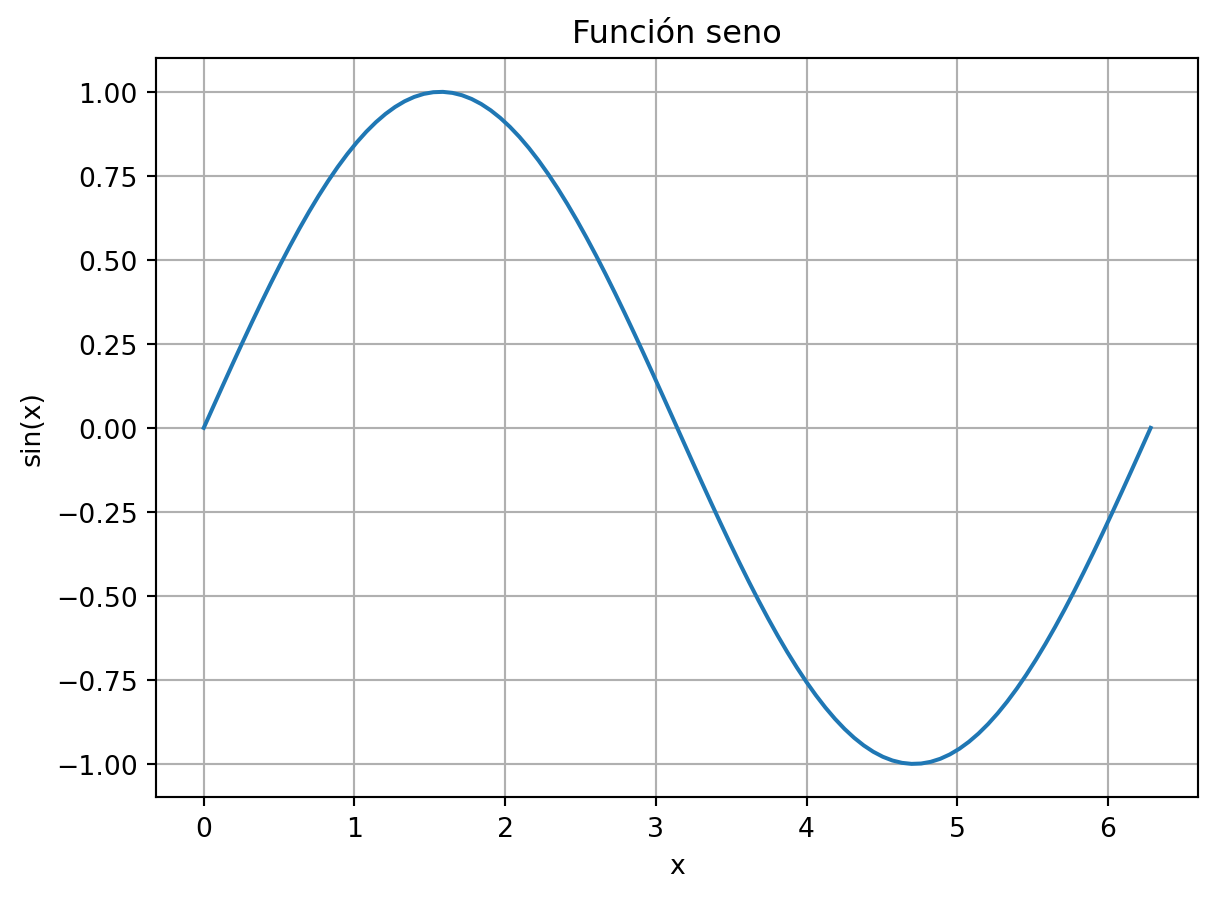

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

# Graficar
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Función seno')
plt.grid(True)
plt.show()

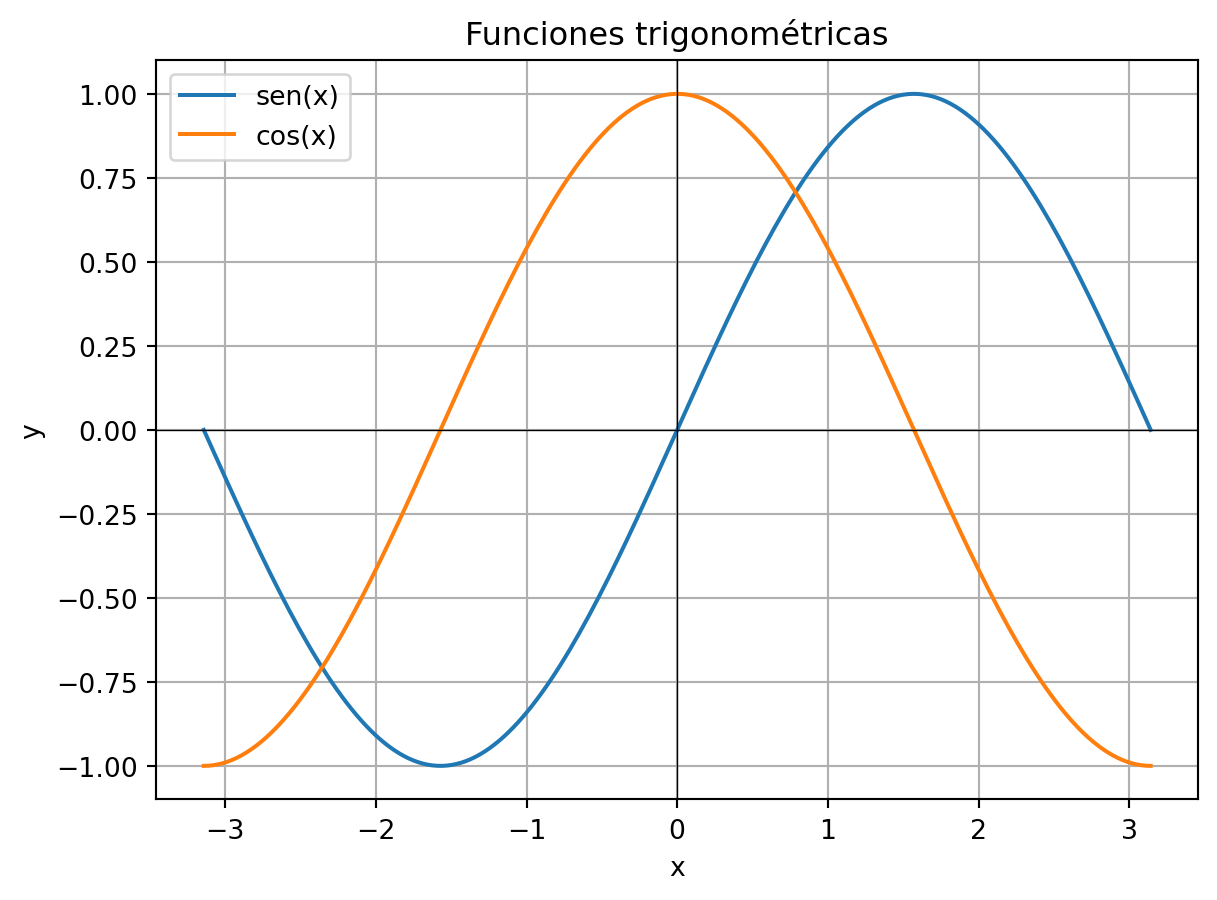

In [82]:
x = np.linspace(-np.pi, np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x, y1, label='sen(x)')
plt.plot(x, y2, label='cos(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Funciones trigonométricas')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

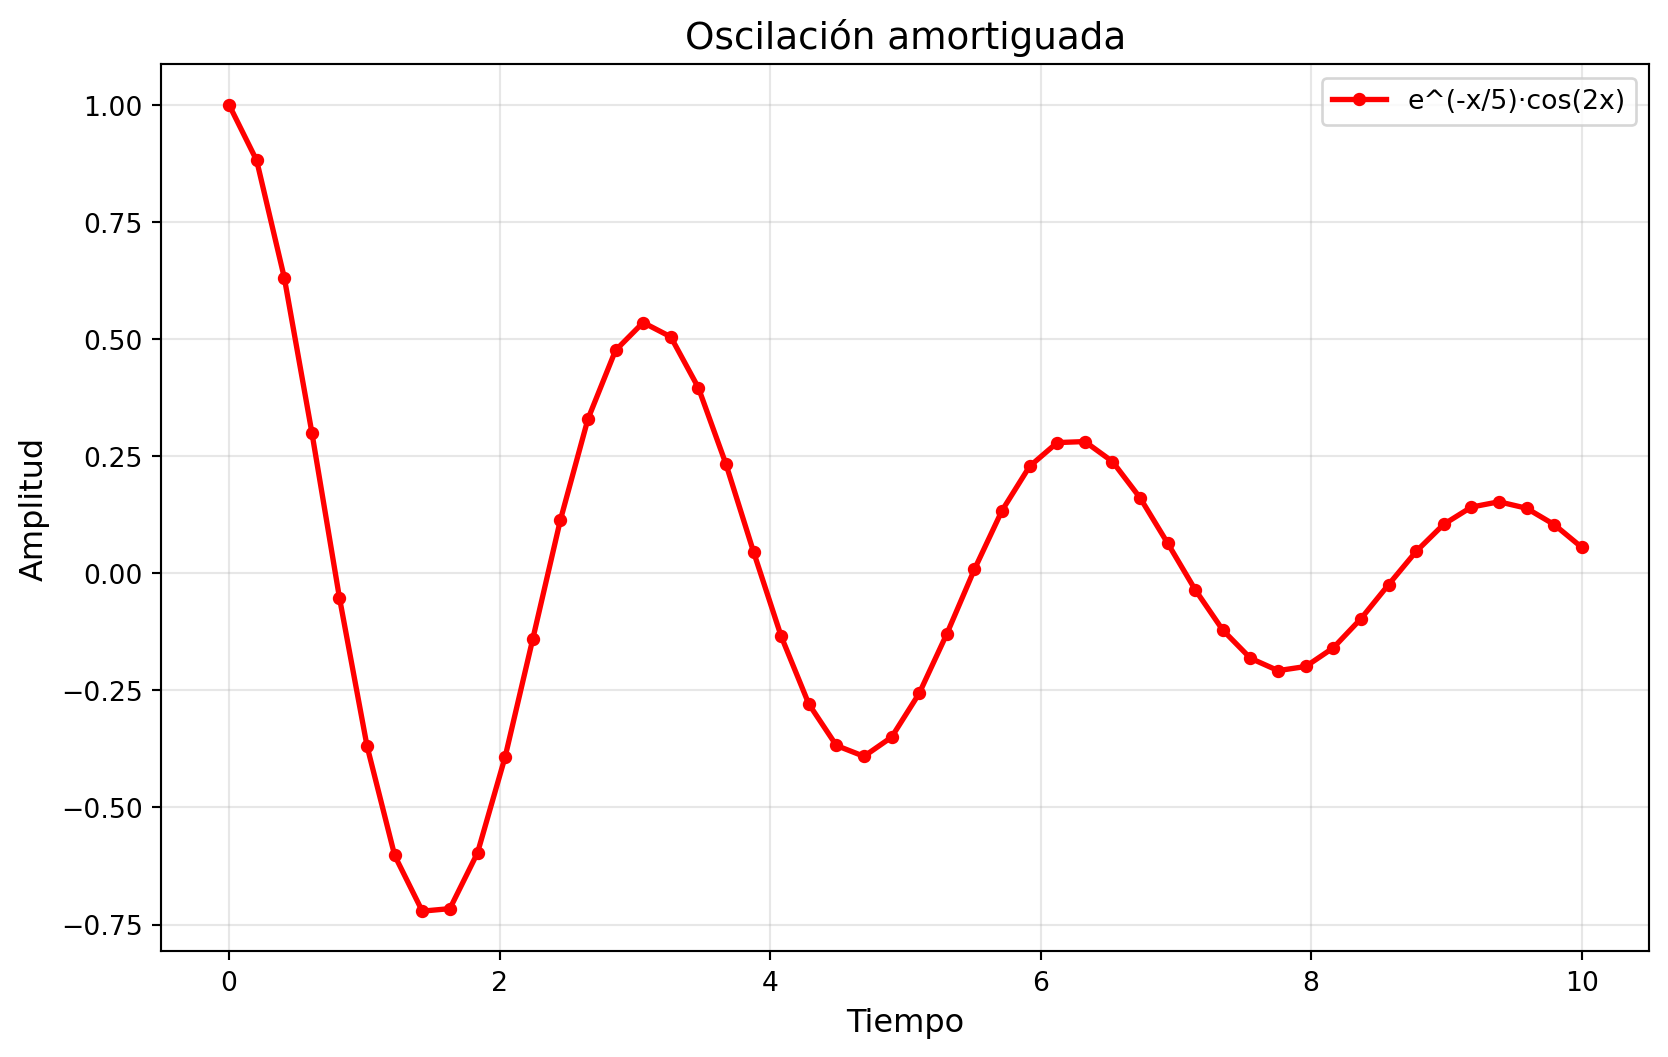

In [83]:
x = np.linspace(0, 10, 50)
y = np.exp(-x/5) * np.cos(2*x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro-', linewidth=2, markersize=4, label='e^(-x/5)·cos(2x)')
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.title('Oscilación amortiguada', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

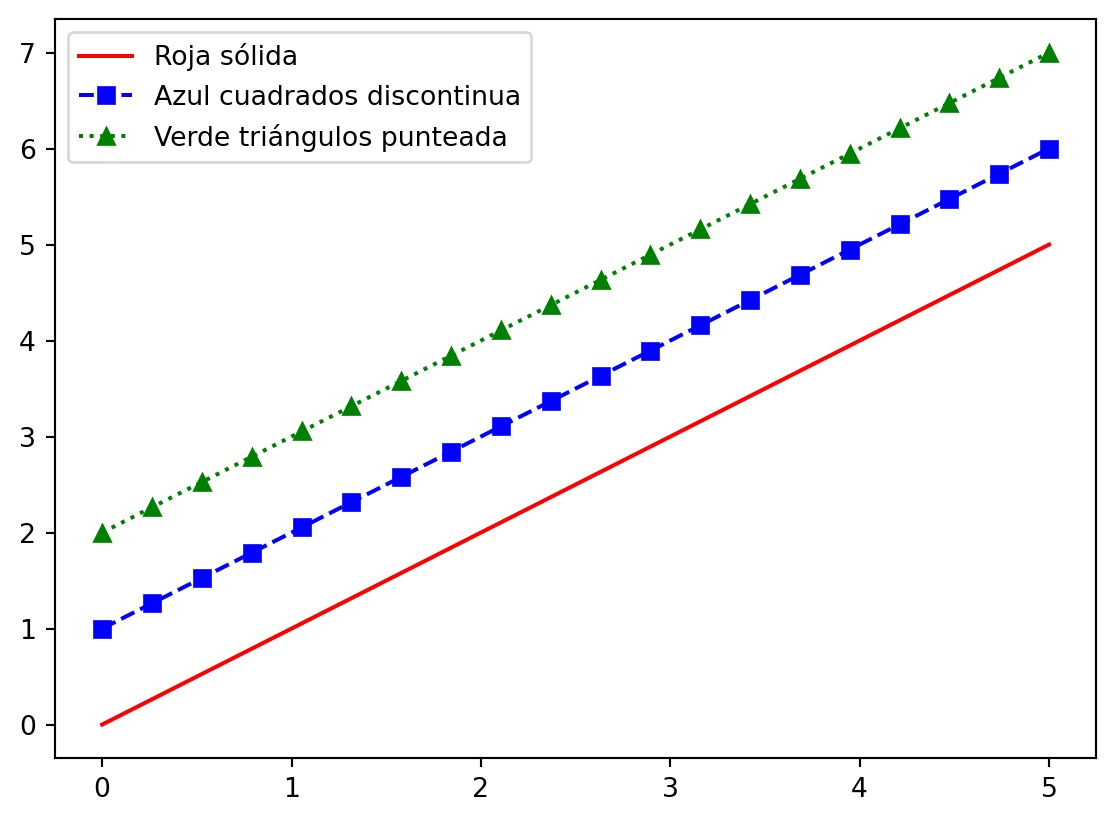

In [84]:
x = np.linspace(0, 5, 20)

plt.plot(x, x, 'r-', label='Roja sólida')
plt.plot(x, x+1, 'bs--', label='Azul cuadrados discontinua')
plt.plot(x, x+2, 'g^:', label='Verde triángulos punteada')
plt.legend()
plt.show()

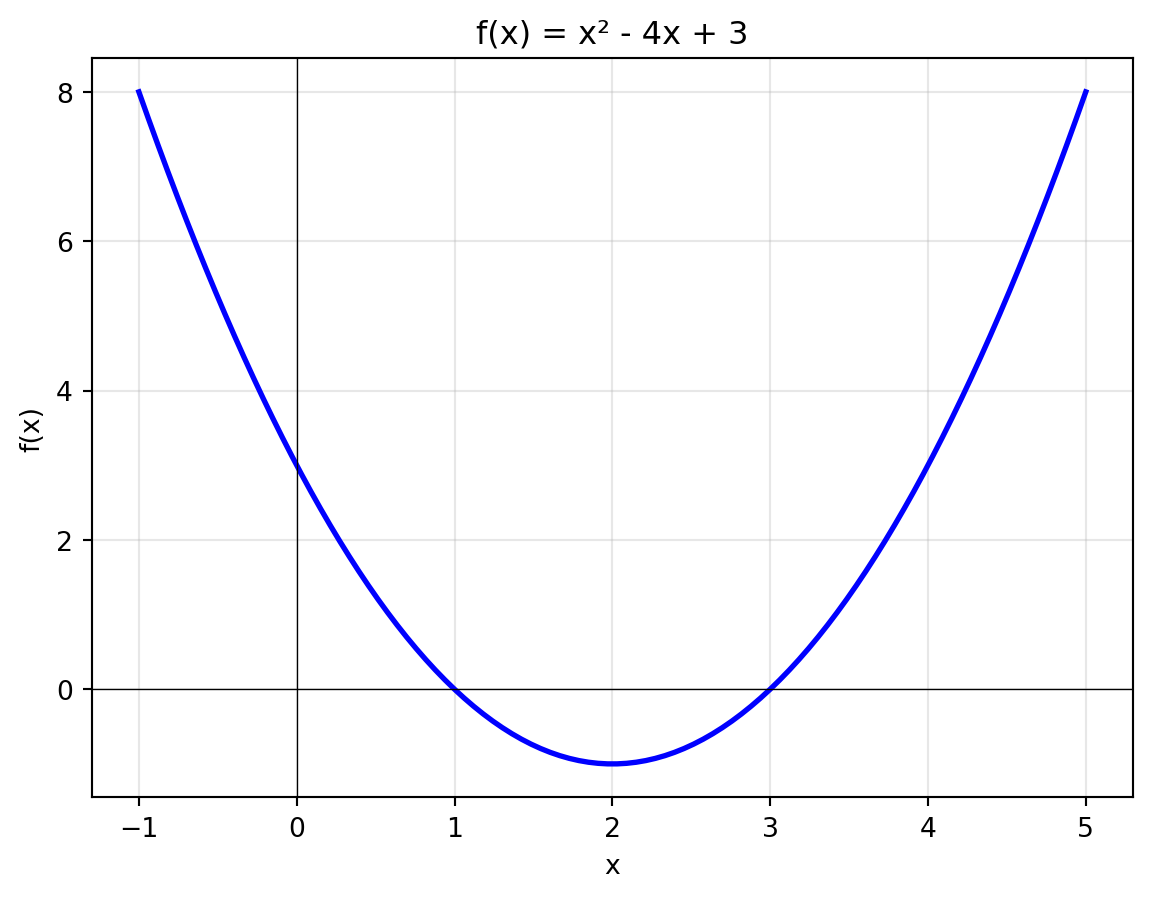

In [85]:
# Función lambda
f = lambda x: x**2 - 4*x + 3

# Graficar
x = np.linspace(-1, 5, 100)
y = f(x)

plt.plot(x, y, 'b-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title('f(x) = x² - 4x + 3')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

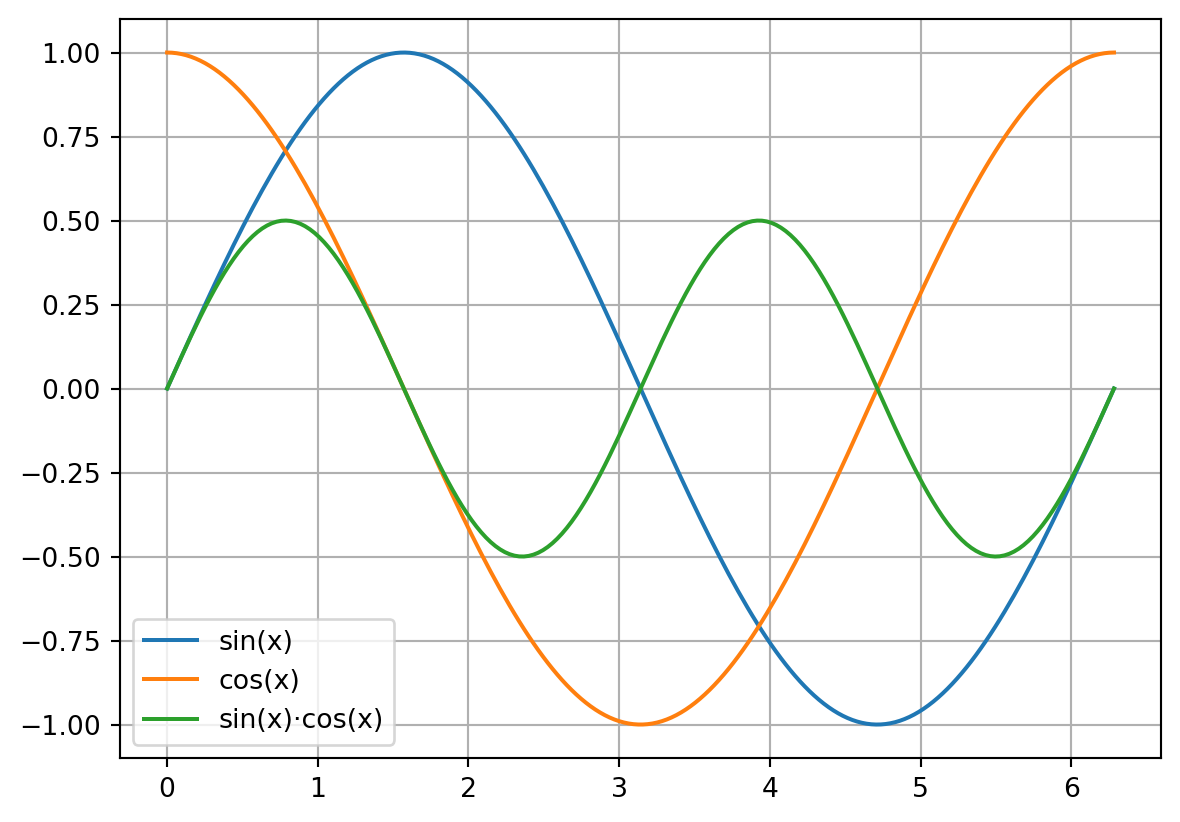

In [86]:
# Múltiples funciones
f1 = lambda x: np.sin(x)
f2 = lambda x: np.cos(x)
f3 = lambda x: np.sin(x) * np.cos(x)

x = np.linspace(0, 2*np.pi, 200)

plt.plot(x, f1(x), label='sin(x)')
plt.plot(x, f2(x), label='cos(x)')
plt.plot(x, f3(x), label='sin(x)·cos(x)')
plt.legend()
plt.grid(True)
plt.show()

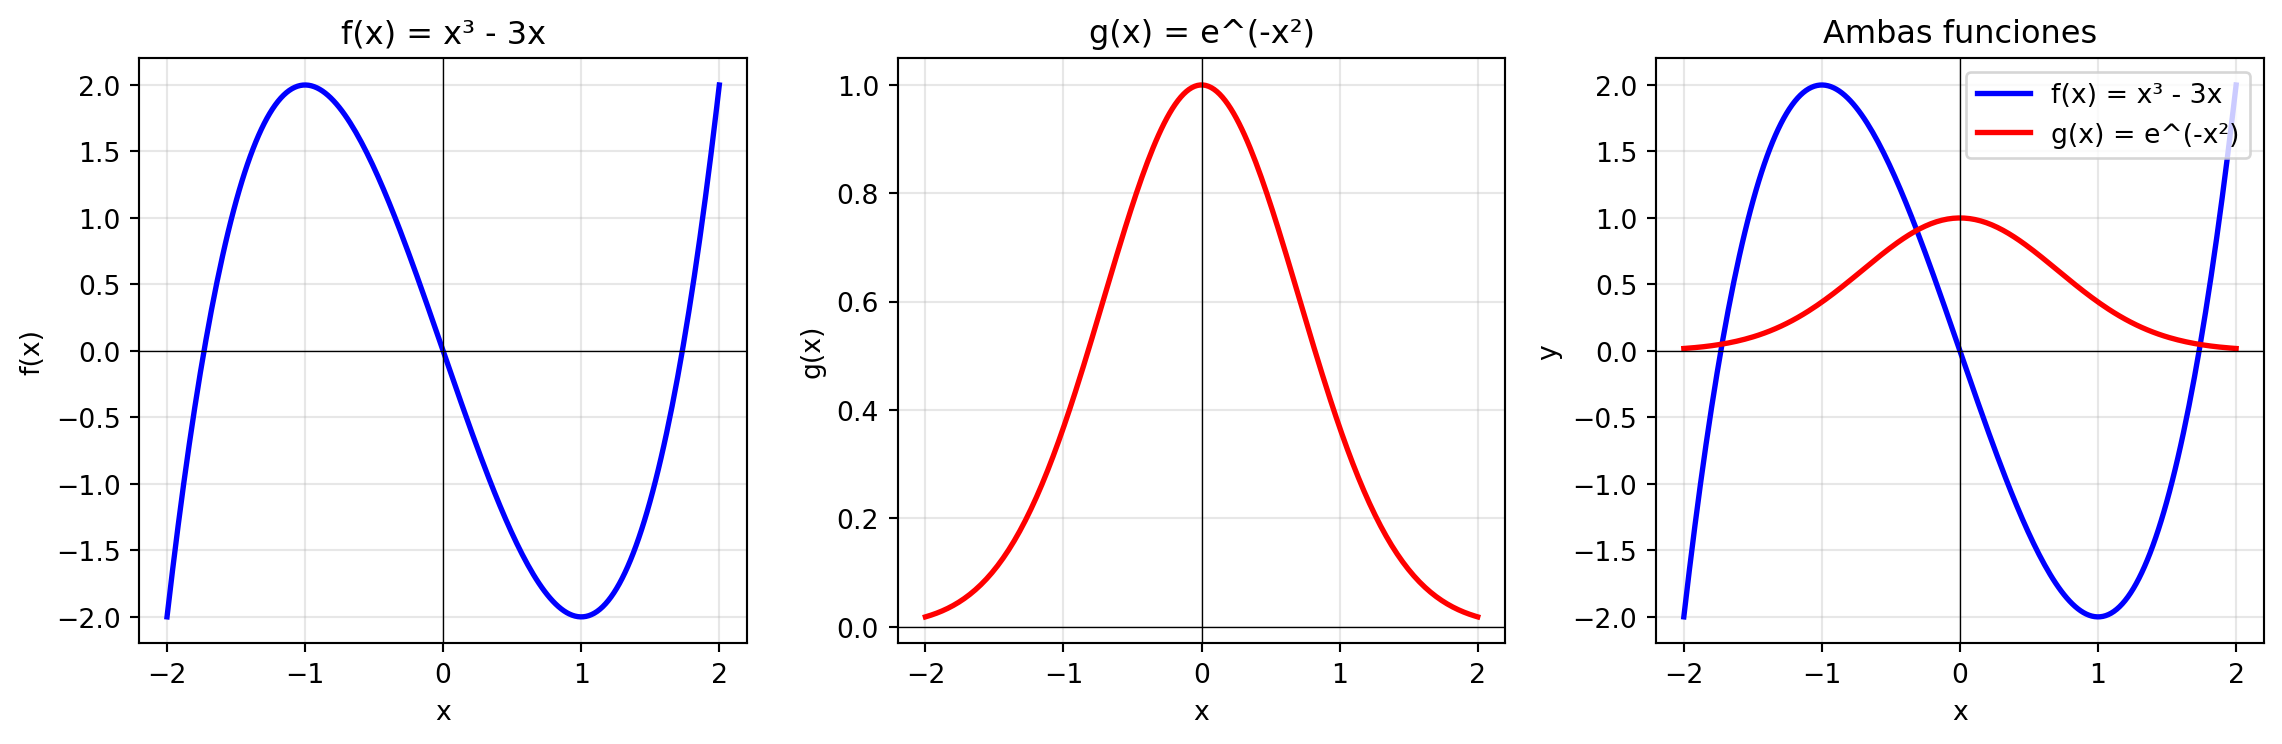

In [87]:
# a) f(x) = x³ - 3x
f = lambda x: x**3 - 3*x
x = np.linspace(-2, 2, 200)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, f(x), 'b-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title('f(x) = x³ - 3x')
plt.xlabel('x')
plt.ylabel('f(x)')

# b) g(x) = e^(-x²)
g = lambda x: np.exp(-x**2)

plt.subplot(1, 3, 2)
plt.plot(x, g(x), 'r-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title('g(x) = e^(-x²)')
plt.xlabel('x')
plt.ylabel('g(x)')

# c) Ambas juntas
plt.subplot(1, 3, 3)
plt.plot(x, f(x), 'b-', linewidth=2, label='f(x) = x³ - 3x')
plt.plot(x, g(x), 'r-', linewidth=2, label='g(x) = e^(-x²)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.title('Ambas funciones')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

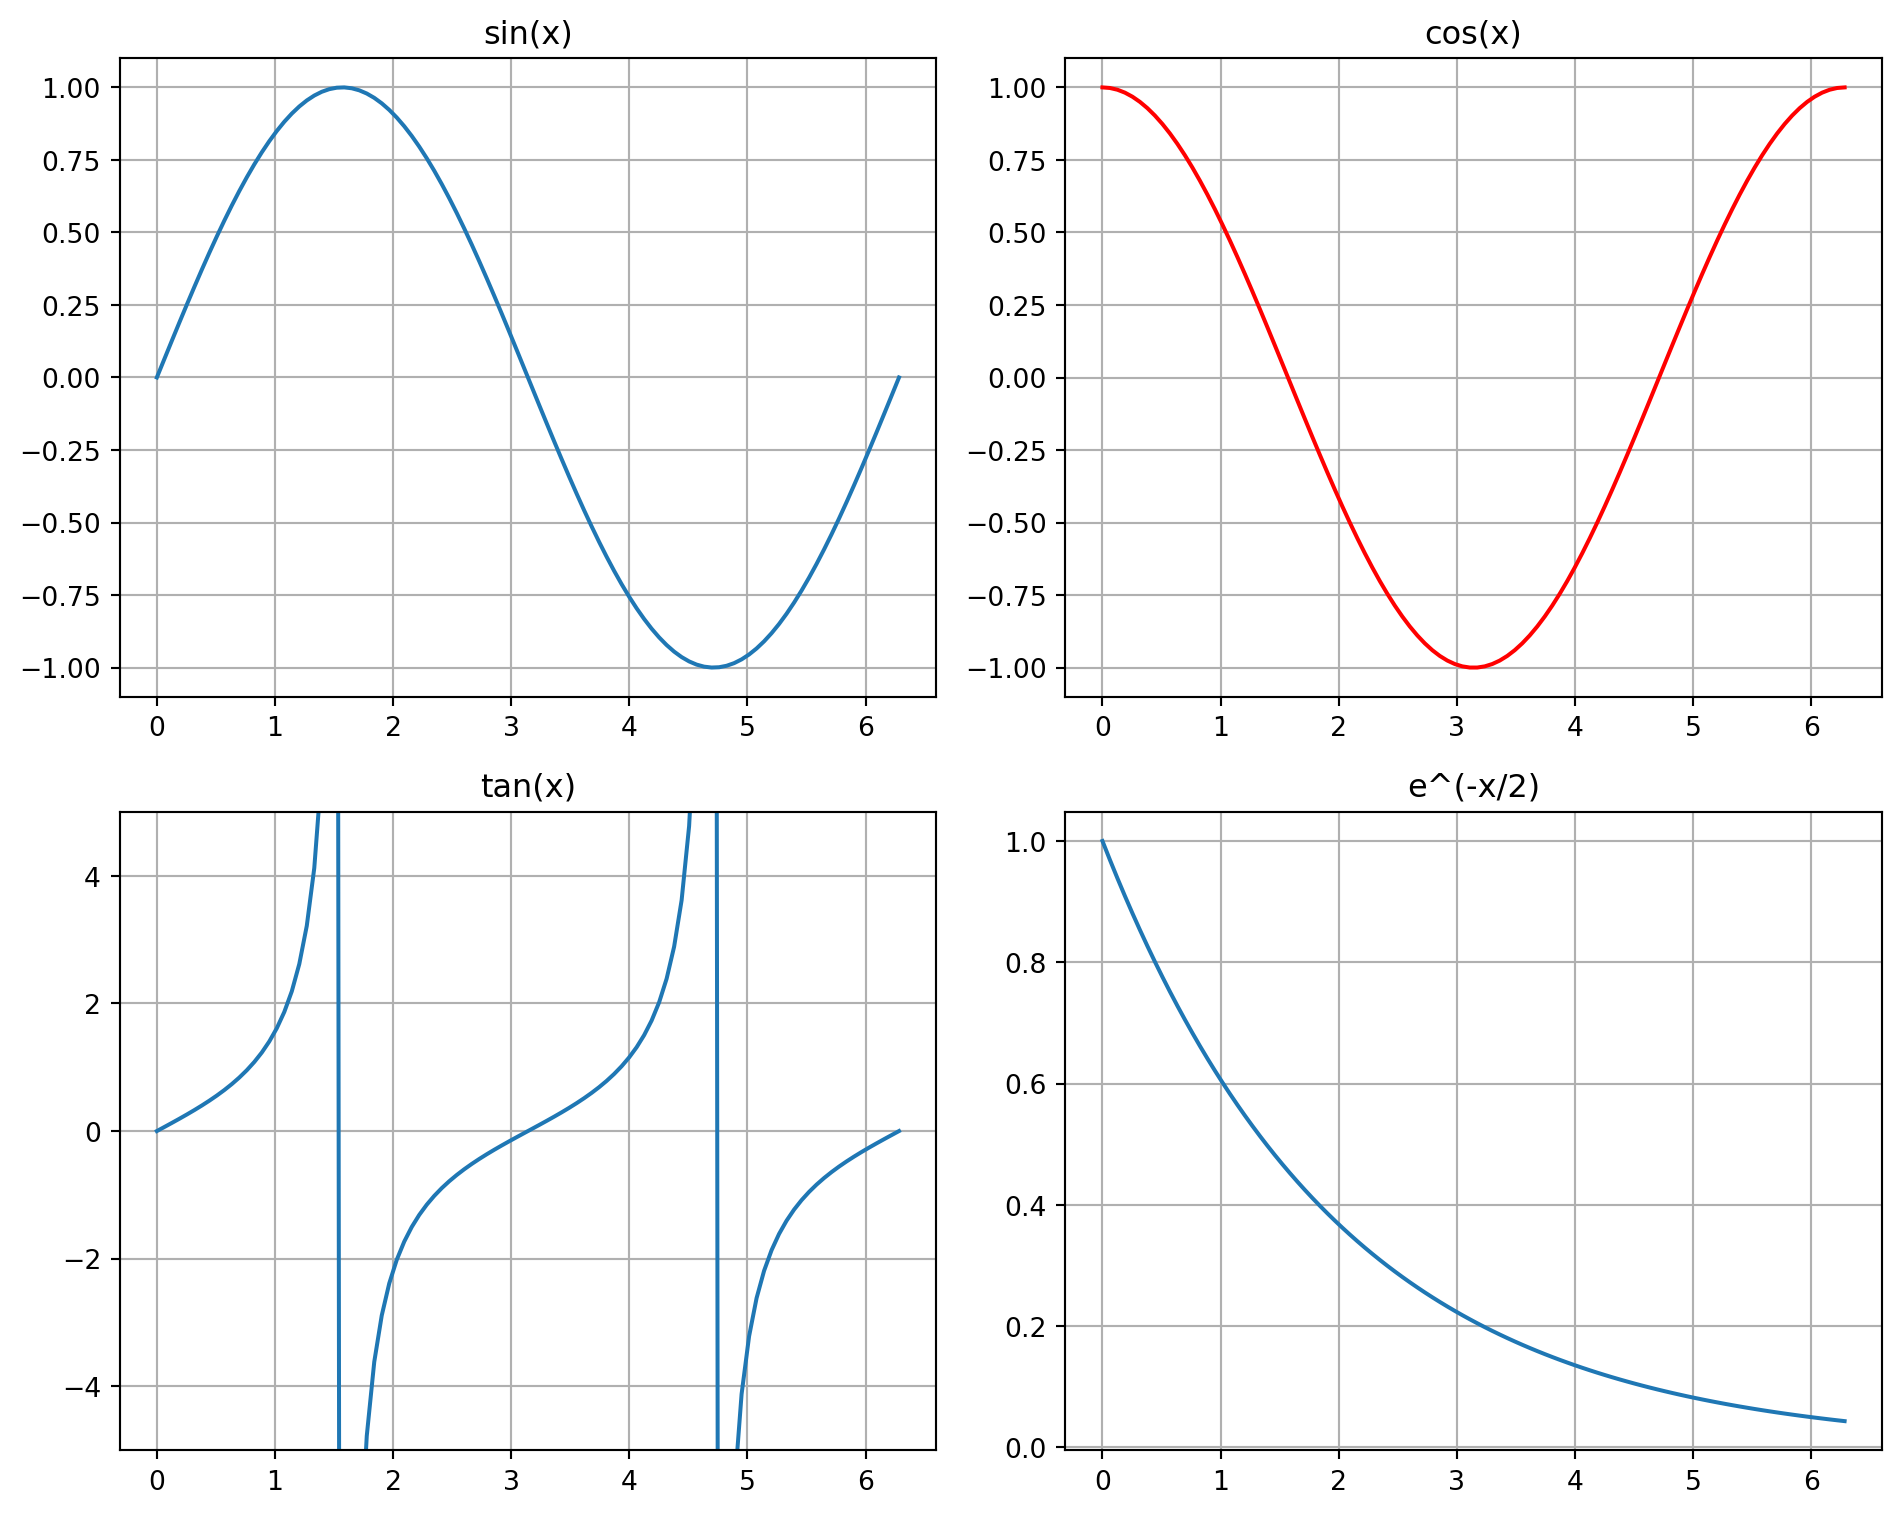

In [88]:
#| fig-cap: "Ejemplo de subplots"

# Subplots: múltiples gráficos en una figura
x = np.linspace(0, 2*np.pi, 100)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# subplot (0,0)
axs[0, 0].plot(x, np.sin(x))
axs[0, 0].set_title('sin(x)')
axs[0, 0].grid(True)

# subplot (0,1)
axs[0, 1].plot(x, np.cos(x), 'r')
axs[0, 1].set_title('cos(x)')
axs[0, 1].grid(True)

# subplot (1,0)
axs[1, 0].plot(x, np.tan(x))
axs[1, 0].set_title('tan(x)')
axs[1, 0].set_ylim(-5, 5)
axs[1, 0].grid(True)

# subplot (1,1)
axs[1, 1].plot(x, np.exp(-x/2))
axs[1, 1].set_title('e^(-x/2)')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

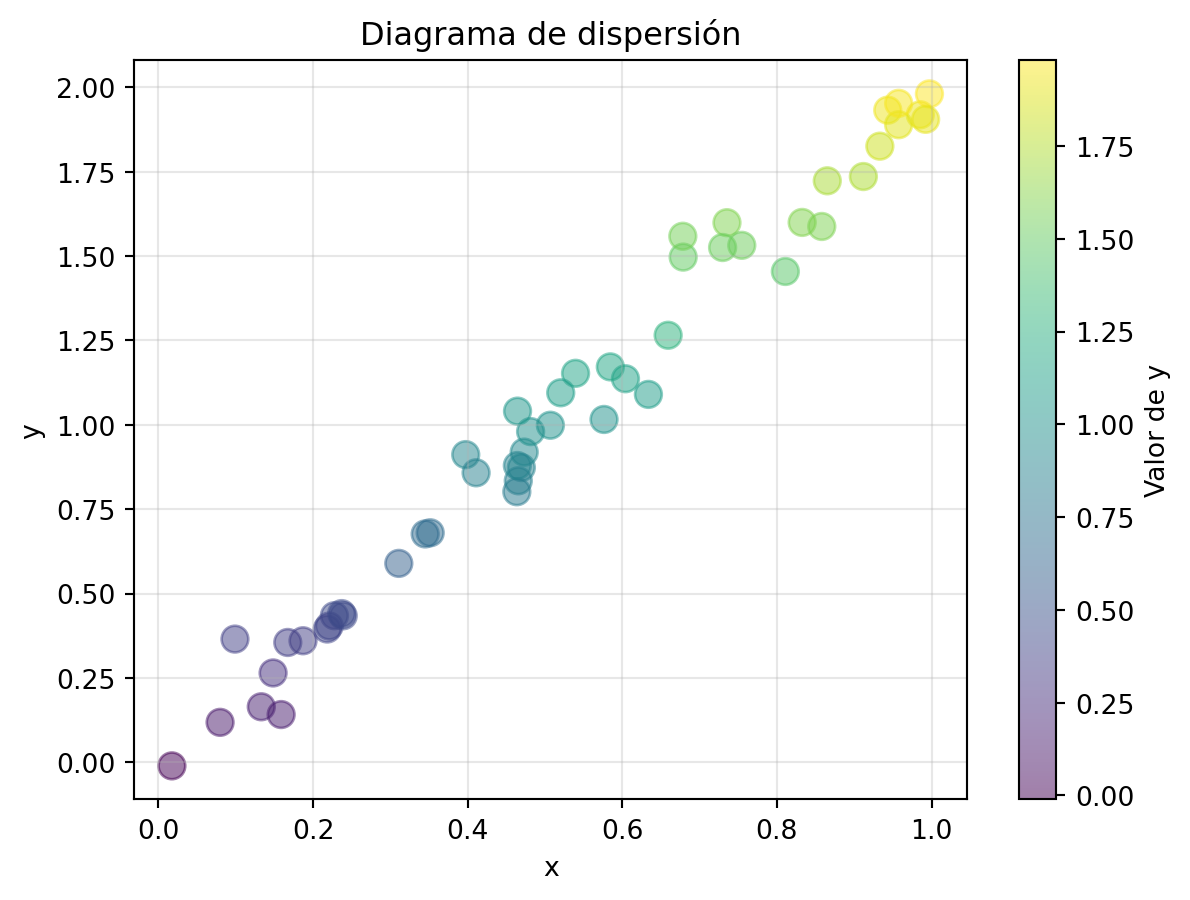

In [89]:
#| fig-cap: "Gráfico de dispersión"

# Scatter plot (diagrama de dispersión)
n = 50
x = np.random.rand(n)
y = 2*x + np.random.randn(n)*0.1

plt.scatter(x, y, alpha=0.5, s=100, c=y, cmap='viridis')
plt.colorbar(label='Valor de y')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Diagrama de dispersión')
plt.grid(True, alpha=0.3)
plt.show()

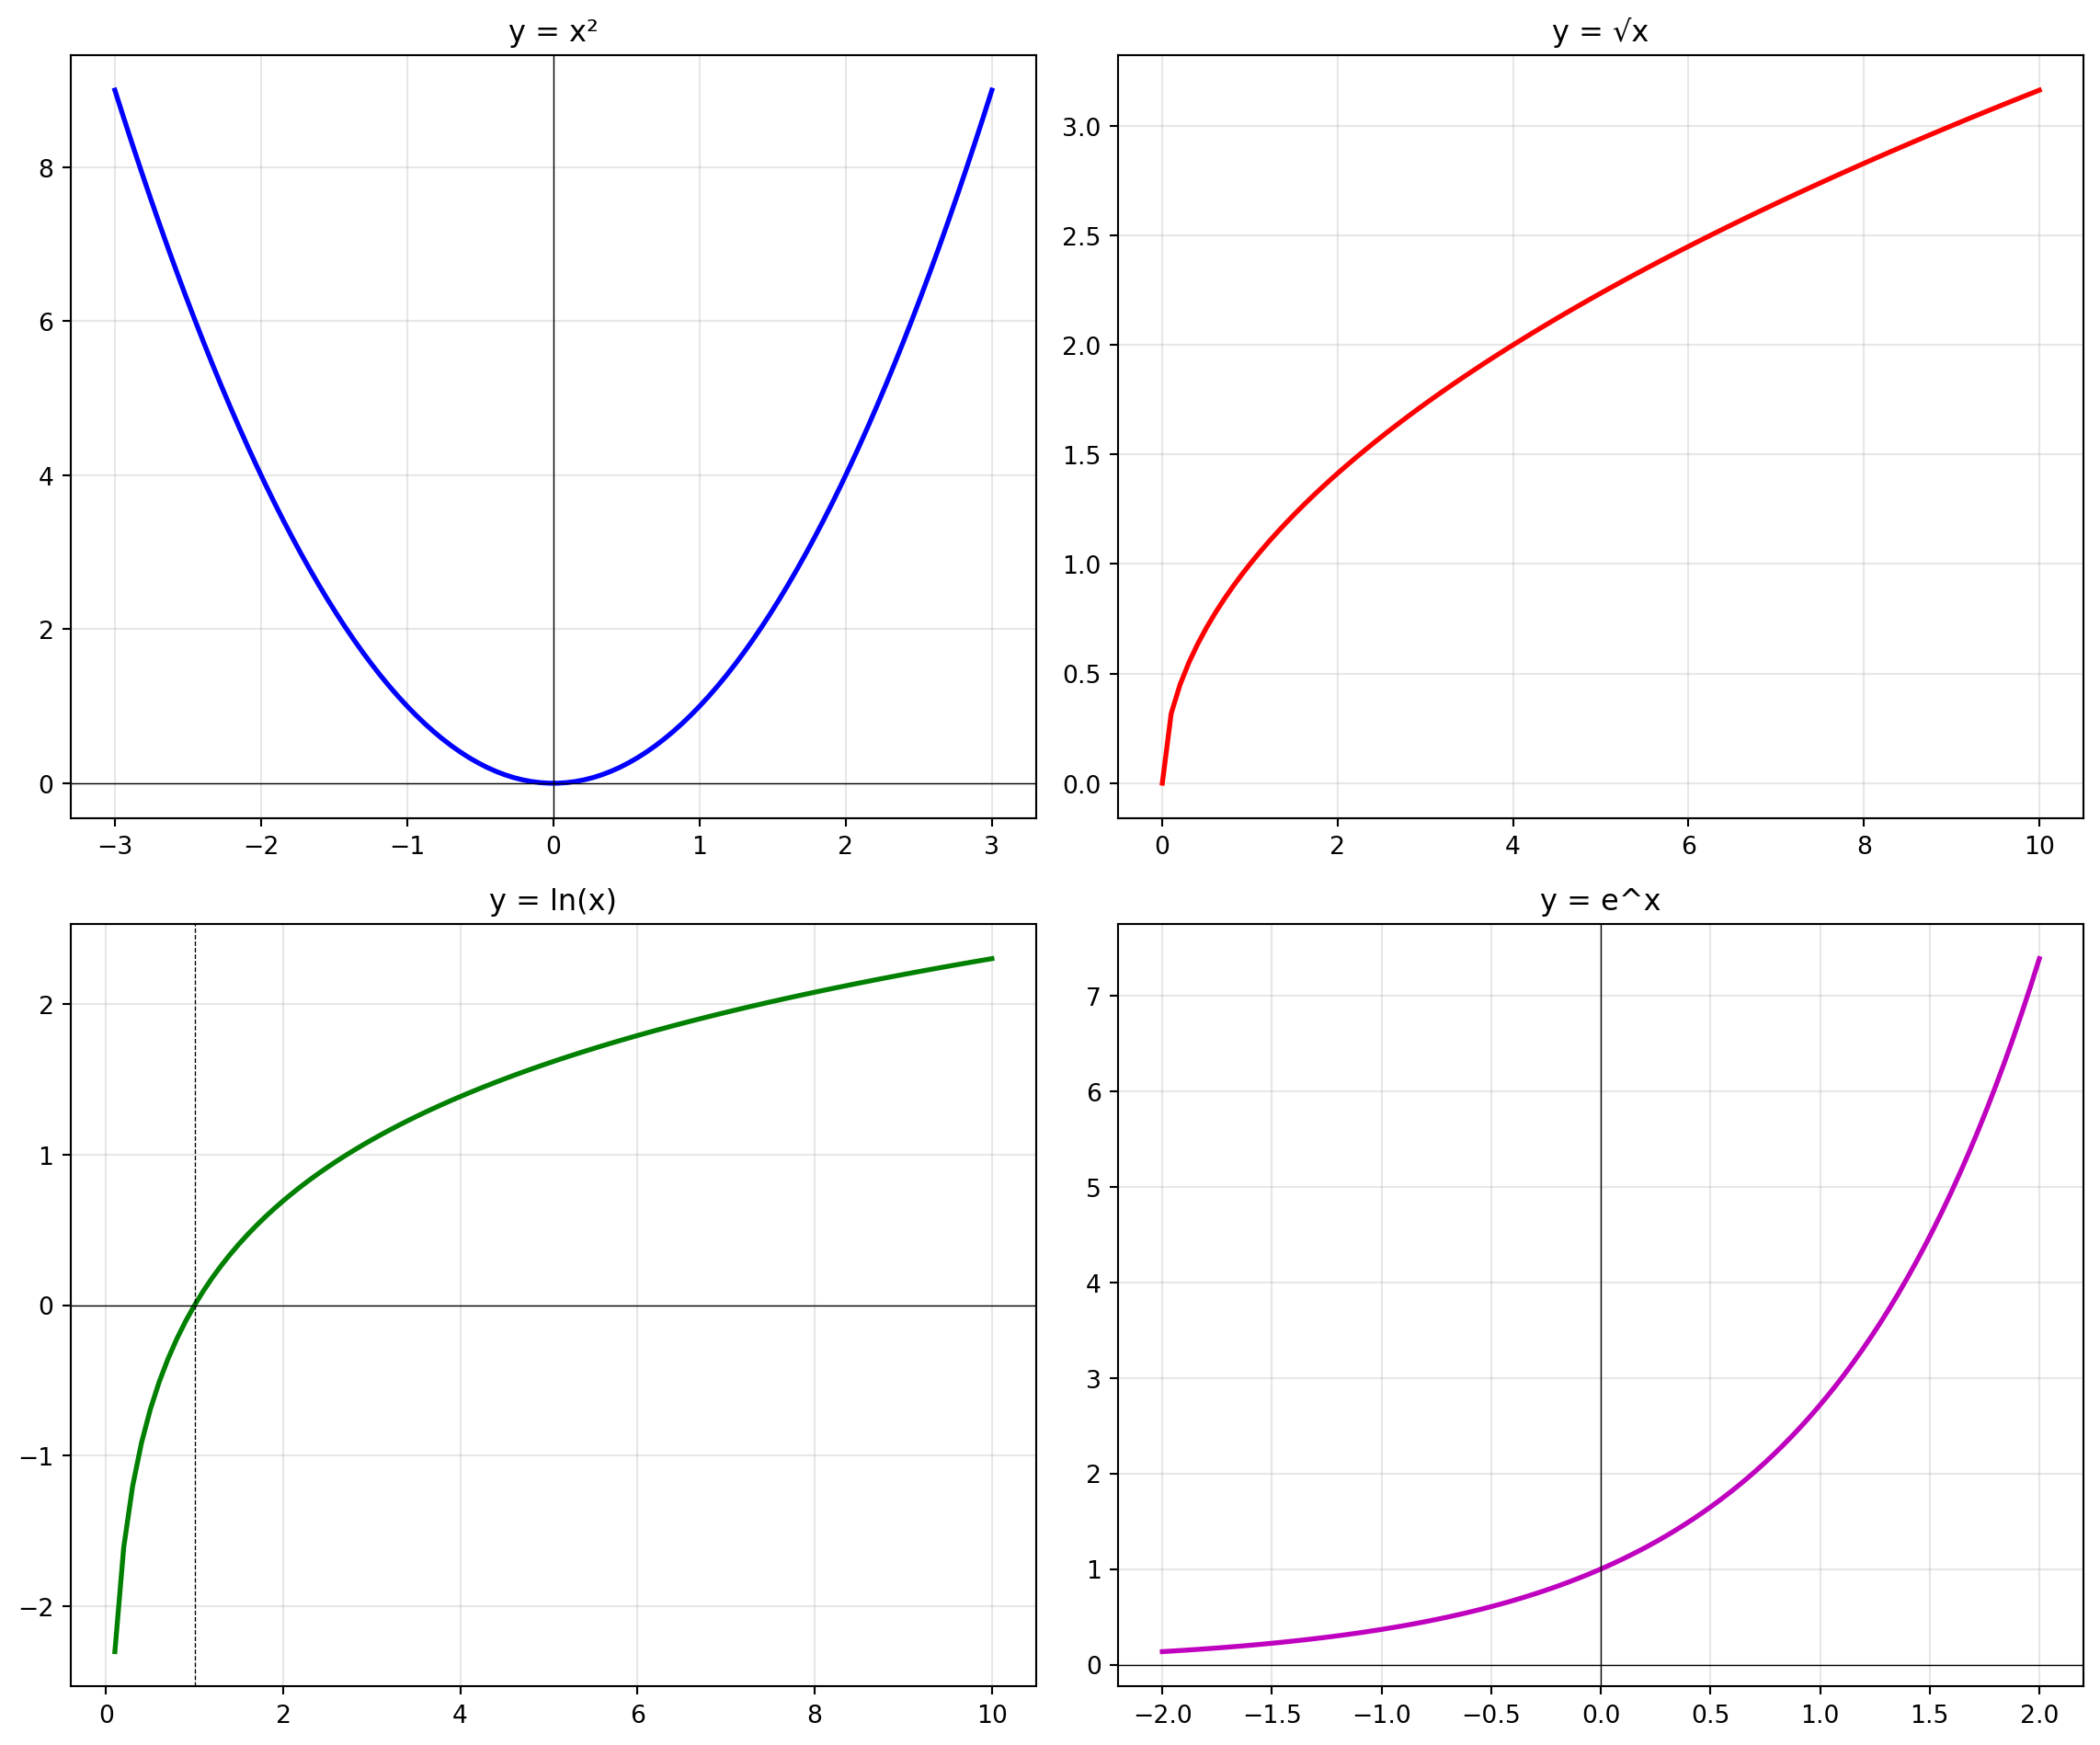

In [90]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Top izquierda: x²
x1 = np.linspace(-3, 3, 100)
axs[0, 0].plot(x1, x1**2, 'b-', linewidth=2)
axs[0, 0].set_title('y = x²')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].axhline(y=0, color='k', linewidth=0.5)
axs[0, 0].axvline(x=0, color='k', linewidth=0.5)

# Top derecha: √x
x2 = np.linspace(0, 10, 100)
axs[0, 1].plot(x2, np.sqrt(x2), 'r-', linewidth=2)
axs[0, 1].set_title('y = √x')
axs[0, 1].grid(True, alpha=0.3)

# Bottom izquierda: ln(x)
x3 = np.linspace(0.1, 10, 100)
axs[1, 0].plot(x3, np.log(x3), 'g-', linewidth=2)
axs[1, 0].set_title('y = ln(x)')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].axhline(y=0, color='k', linewidth=0.5)
axs[1, 0].axvline(x=1, color='k', linewidth=0.5, linestyle='--')

# Bottom derecha: e^x
x4 = np.linspace(-2, 2, 100)
axs[1, 1].plot(x4, np.exp(x4), 'm-', linewidth=2)
axs[1, 1].set_title('y = e^x')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].axhline(y=0, color='k', linewidth=0.5)
axs[1, 1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

In [91]:
# Definir una función
def saludar(nombre):
    """Función que saluda a una persona"""
    return f"Hola, {nombre}!"

# Usar la función
mensaje = saludar("María")
print(mensaje)

Hola, María!


In [92]:
# Función con múltiples parámetros
def suma_cuadrados(a, b):
    """Retorna la suma de los cuadrados de a y b"""
    return a**2 + b**2

resultado = suma_cuadrados(3, 4)
print(f"3² + 4² = {resultado}")

3² + 4² = 25


In [93]:
# Función con valores por defecto
def potencia(base, exponente=2):
    """Eleva base a la potencia exponente (por defecto 2)"""
    return base ** exponente

print(f"5² = {potencia(5)}")
print(f"2³ = {potencia(2, 3)}")

5² = 25
2³ = 8


In [94]:
import numpy as np

# Generar vector aleatorio
np.random.seed(42)  # Para reproducibilidad
datos = np.random.uniform(0, 100, 10)

# Calcular estadísticas
media = np.mean(datos)
mediana = np.median(datos)
desv_std = np.std(datos)

# Imprimir resultados
print("Datos:", datos)
print(f"\nMedia: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desv_std:.2f}")

Datos: [37.45401188 95.07143064 73.19939418 59.86584842 15.60186404 15.59945203
  5.80836122 86.61761458 60.11150117 70.80725778]

Media: 52.01
Mediana: 59.99
Desviación estándar: 29.97


In [95]:
import numpy as np

def resolver_cuadratica(a, b, c):
    """
    Resuelve la ecuación cuadrática ax² + bx + c = 0
    
    Parámetros:
        a, b, c: coeficientes de la ecuación
    
    Retorna:
        tuple: (x1, x2) las dos raíces
    """
    if a == 0:
        if b == 0:
            return None  # No hay solución o infinitas soluciones
        else:
            return (-c/b, None)  # Ecuación lineal
    
    discriminante = b**2 - 4*a*c
    
    if discriminante >= 0:
        # Raíces reales
        x1 = (-b + np.sqrt(discriminante)) / (2*a)
        x2 = (-b - np.sqrt(discriminante)) / (2*a)
    else:
        # Raíces complejas
        x1 = (-b + np.sqrt(discriminante + 0j)) / (2*a)
        x2 = (-b - np.sqrt(discriminante + 0j)) / (2*a)
    
    return (x1, x2)

# Probar la función
print("x² - 5x + 6 = 0:")
x1, x2 = resolver_cuadratica(1, -5, 6)
print(f"  x1 = {x1}, x2 = {x2}")

print("\nx² + 2x + 5 = 0 (raíces complejas):")
x1, x2 = resolver_cuadratica(1, 2, 5)
print(f"  x1 = {x1}")
print(f"  x2 = {x2}")

x² - 5x + 6 = 0:
  x1 = 3.0, x2 = 2.0

x² + 2x + 5 = 0 (raíces complejas):
  x1 = (-1+2j)
  x2 = (-1-2j)


In [96]:
#| eval: false

# Supongamos que tenemos un archivo 'datos.txt' con:
# 1.0 2.0 3.0
# 4.0 5.0 6.0
# 7.0 8.0 9.0

datos = np.loadtxt('datos.txt')
print(datos)

In [97]:
#| eval: false

# Con NumPy
datos_csv = np.loadtxt('datos.csv', delimiter=',')

# Con pandas (más versátil)
import pandas as pd
df = pd.read_csv('datos.csv')
print(df.head())  # Primeras 5 filas

In [98]:
import numpy as np

# Crear datos
datos = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])

# Guardar en archivo
np.savetxt('mi_datos.txt', datos, fmt='%.2f')

# Leer del archivo
datos_leidos = np.loadtxt('mi_datos.txt')
print("Datos leídos:")
print(datos_leidos)

Datos leídos:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


In [99]:
#| eval: false

# Saltar filas de encabezado
datos = np.loadtxt('archivo.txt', skiprows=1)

# Usar columnas específicas
datos = np.loadtxt('archivo.txt', usecols=(0, 2))  # Columnas 0 y 2

# Especificar delimitador
datos = np.loadtxt('archivo.txt', delimiter=';')

# Especificar tipo de datos
datos = np.loadtxt('archivo.txt', dtype=int)

In [100]:
import numpy as np

# Crear datos
x = np.linspace(0, 2*np.pi, 10)
y = np.sin(x)

# Guardar como dos columnas
datos = np.column_stack((x, y))
np.savetxt('seno.txt', datos, header='x sin(x)', fmt='%.6f')

# Leer y verificar
datos_leidos = np.loadtxt('seno.txt')
print("Primeras 5 filas:")
print(datos_leidos[:5])

Primeras 5 filas:
[[0.       0.      ]
 [0.698132 0.642788]
 [1.396263 0.984808]
 [2.094395 0.866025]
 [2.792527 0.34202 ]]


In [101]:
import numpy as np

# 1. Crear vector x
x = np.linspace(0, 10, 20)

# 2. Calcular y y z
y = x**2
z = np.sin(x)

# 3. Guardar en archivo
datos = np.column_stack((x, y, z))
np.savetxt('funciones.txt', datos, 
           header='x x^2 sin(x)', 
           fmt='%.6f',
           comments='# ')

print("Archivo guardado exitosamente")

# 4. Leer y verificar
datos_leidos = np.loadtxt('funciones.txt')
print("\nPrimeras 5 filas del archivo:")
print(datos_leidos[:5])

# Verificación
print("\nVerificación (diferencia debe ser ~0):")
print(f"Diferencia en x: {np.max(np.abs(datos_leidos[:, 0] - x)):.2e}")
print(f"Diferencia en y: {np.max(np.abs(datos_leidos[:, 1] - y)):.2e}")
print(f"Diferencia en z: {np.max(np.abs(datos_leidos[:, 2] - z)):.2e}")

Archivo guardado exitosamente

Primeras 5 filas del archivo:
[[0.       0.       0.      ]
 [0.526316 0.277008 0.502351]
 [1.052632 1.108033 0.86873 ]
 [1.578947 2.493075 0.999967]
 [2.105263 4.432133 0.86054 ]]

Verificación (diferencia debe ser ~0):
Diferencia en x: 4.74e-07
Diferencia en y: 4.79e-07
Diferencia en z: 4.74e-07


In [102]:
# if simple
x = 10

if x > 0:
    print("x es positivo")

x es positivo


In [103]:
# if-else
x = -5

if x > 0:
    print("x es positivo")
else:
    print("x es negativo o cero")

x es negativo o cero


In [104]:
# if-elif-else
x = 0

if x > 0:
    print("x es positivo")
elif x < 0:
    print("x es negativo")
else:
    print("x es cero")

x es cero


In [105]:
a = 5
b = 10

print(f"{a} == {b}: {a == b}")
print(f"{a} < {b}: {a < b}")
print(f"{a} != {b}: {a != b}")

5 == 10: False
5 < 10: True
5 != 10: True


In [106]:
x = 15

if x > 10 and x < 20:
    print("x está entre 10 y 20")

if x < 5 or x > 10:
    print("x es menor que 5 o mayor que 10")

if not (x < 0):
    print("x no es negativo")

x está entre 10 y 20
x es menor que 5 o mayor que 10
x no es negativo


In [107]:
import numpy as np

# Determinar tipo de número
numero = -7

if numero > 0:
    print(f"{numero} es positivo")
    if numero % 2 == 0:
        print("  y es par")
    else:
        print("  y es impar")
elif numero < 0:
    print(f"{numero} es negativo")
else:
    print("El número es cero")

-7 es negativo


In [108]:
# Iterar sobre una lista
for i in [1, 2, 3, 4, 5]:
    print(f"Número: {i}")

Número: 1
Número: 2
Número: 3
Número: 4
Número: 5


In [109]:
# Usar range()
for i in range(5):
    print(f"Iteración {i}")

Iteración 0
Iteración 1
Iteración 2
Iteración 3
Iteración 4


In [110]:
# Calcular suma de cuadrados
suma = 0
for i in range(1, 6):
    suma += i**2
print(f"Suma de cuadrados de 1 a 5: {suma}")

Suma de cuadrados de 1 a 5: 55


In [111]:
# Iterar sobre un array
numeros = np.array([10, 20, 30, 40, 50])

for num in numeros:
    print(f"{num} → {num**2}")

10 → 100
20 → 400
30 → 900
40 → 1600
50 → 2500


In [112]:
nombres = ['Ana', 'Juan', 'María']

for i, nombre in enumerate(nombres):
    print(f"Posición {i}: {nombre}")

Posición 0: Ana
Posición 1: Juan
Posición 2: María


In [113]:
import numpy as np

# Aproximar π usando serie de Leibniz
# π/4 = 1 - 1/3 + 1/5 - 1/7 + 1/9 - ...

n_terminos = 1000
suma = 0

for i in range(n_terminos):
    signo = (-1)**i
    denominador = 2*i + 1
    suma += signo / denominador

pi_aproximado = 4 * suma
print(f"Aproximación de π con {n_terminos} términos: {pi_aproximado}")
print(f"Valor real de π: {np.pi}")
print(f"Error: {abs(pi_aproximado - np.pi):.6f}")

Aproximación de π con 1000 términos: 3.140592653839794
Valor real de π: 3.141592653589793
Error: 0.001000


In [114]:
# Ejemplo básico
contador = 0

while contador < 5:
    print(f"Contador: {contador}")
    contador += 1

Contador: 0
Contador: 1
Contador: 2
Contador: 3
Contador: 4


In [115]:
# Encontrar primer número mayor que 1000 en la secuencia n²
n = 1
while n**2 <= 1000:
    n += 1

print(f"El primer n tal que n² > 1000 es n = {n}")
print(f"Verificación: {n}² = {n**2}")

El primer n tal que n² > 1000 es n = 32
Verificación: 32² = 1024


In [116]:
#| eval: false

# ¡ESTO ES UN BUCLE INFINITO! No ejecutar
# while True:
#     print("Esto nunca termina")

In [117]:
contador = 0
while True:
    print(f"Contador: {contador}")
    contador += 1
    if contador >= 5:
        break  # Salir del bucle

Contador: 0
Contador: 1
Contador: 2
Contador: 3
Contador: 4


In [118]:
# Método de bisección simple para encontrar raíz de f(x) = x² - 2
import numpy as np

def f(x):
    return x**2 - 2

# Intervalo inicial
a = 0
b = 2
tolerancia = 1e-6

while (b - a) > tolerancia:
    c = (a + b) / 2
    
    if f(c) == 0:
        break
    elif f(a) * f(c) < 0:
        b = c
    else:
        a = c

raiz = (a + b) / 2
print(f"Raíz aproximada de x² - 2 = 0: {raiz}")
print(f"√2 real: {np.sqrt(2)}")
print(f"Error: {abs(raiz - np.sqrt(2)):.2e}")

Raíz aproximada de x² - 2 = 0: 1.4142136573791504
√2 real: 1.4142135623730951
Error: 9.50e-08


In [119]:
import numpy as np

# ===== PARTE A =====
print("=== PARTE A ===")

# Generar números
np.random.seed(42)
numeros = np.random.uniform(-10, 10, 20)

# Contar
positivos = 0
negativos = 0
ceros = 0

for num in numeros:
    if num > 0:
        positivos += 1
    elif num < 0:
        negativos += 1
    else:
        ceros += 1

print(f"Positivos: {positivos}")
print(f"Negativos: {negativos}")
print(f"Ceros: {ceros}")

# ===== PARTE B =====
print("\n=== PARTE B ===")

suma = 0
n = 0

while suma <= 1.5:
    n += 1
    suma += 1 / n**2

print(f"El menor n tal que Σ(1/i²) > 1.5 es n = {n}")
print(f"Suma acumulada: {suma:.6f}")

# Verificación
print(f"\nVerificación:")
print(f"Suma con n={n-1}: {sum(1/i**2 for i in range(1, n)):.6f} ≤ 1.5")
print(f"Suma con n={n}: {sum(1/i**2 for i in range(1, n+1)):.6f} > 1.5")

=== PARTE A ===
Positivos: 9
Negativos: 11
Ceros: 0

=== PARTE B ===
El menor n tal que Σ(1/i²) > 1.5 es n = 7
Suma acumulada: 1.511797

Verificación:
Suma con n=6: 1.491389 ≤ 1.5
Suma con n=7: 1.511797 > 1.5


In [120]:
import numpy as np

# Valor exacto
x_exacto = np.pi

# Aproximación
x_aprox = 3.14159

# Errores
error_abs = abs(x_exacto - x_aprox)
error_rel = error_abs / abs(x_exacto)

print(f"Valor exacto: {x_exacto}")
print(f"Aproximación: {x_aprox}")
print(f"Error absoluto: {error_abs:.2e}")
print(f"Error relativo: {error_rel:.2e} ({error_rel*100:.4f}%)")

Valor exacto: 3.141592653589793
Aproximación: 3.14159
Error absoluto: 2.65e-06
Error relativo: 8.45e-07 (0.0001%)


In [121]:
import sys

print(f"Máximo flotante: {sys.float_info.max}")
print(f"Mínimo flotante positivo: {sys.float_info.min}")
print(f"Epsilon de máquina: {sys.float_info.epsilon}")

Máximo flotante: 1.7976931348623157e+308
Mínimo flotante positivo: 2.2250738585072014e-308
Epsilon de máquina: 2.220446049250313e-16


In [122]:
eps = np.finfo(float).eps
print(f"Epsilon de máquina: {eps}")

# Verificar
print(f"1 + eps == 1: {1 + eps == 1}")
print(f"1 + eps > 1: {1 + eps > 1}")
print(f"1 + eps/2 == 1: {1 + eps/2 == 1}")

Epsilon de máquina: 2.220446049250313e-16
1 + eps == 1: False
1 + eps > 1: True
1 + eps/2 == 1: True


In [123]:
# Ejemplo clásico
a = 0.1
b = 0.2
c = 0.3

print(f"0.1 + 0.2 = {a + b}")
print(f"0.1 + 0.2 == 0.3: {a + b == c}")
print(f"Diferencia: {abs((a + b) - c):.2e}")

0.1 + 0.2 = 0.30000000000000004
0.1 + 0.2 == 0.3: False
Diferencia: 5.55e-17


In [124]:
# MAL
x = 0.1 + 0.2
if x == 0.3:
    print("Son iguales")  # Esto NO se ejecutará
else:
    print("No son iguales")

# BIEN: usar tolerancia
tolerancia = 1e-10
if abs(x - 0.3) < tolerancia:
    print("Son aproximadamente iguales")

No son iguales
Son aproximadamente iguales


In [125]:
import numpy as np

x = 0.1 + 0.2
y = 0.3

print(f"np.isclose(x, y): {np.isclose(x, y)}")
print(f"np.allclose([x], [y]): {np.allclose([x], [y])}")

np.isclose(x, y): True
np.allclose([x], [y]): True


In [126]:
# Sumar 0.1 muchas veces
suma = 0.0
for i in range(10):
    suma += 0.1

print(f"Suma de 0.1 diez veces: {suma}")
print(f"Debería ser 1.0")
print(f"Diferencia: {abs(suma - 1.0):.2e}")

Suma de 0.1 diez veces: 0.9999999999999999
Debería ser 1.0
Diferencia: 1.11e-16


In [127]:
# Versión más precisa
n = 10
suma_exacta = n * 0.1
print(f"Multiplicación directa: {suma_exacta}")
print(f"Diferencia: {abs(suma_exacta - 1.0):.2e}")

Multiplicación directa: 1.0
Diferencia: 0.00e+00


In [128]:
# Ejemplo: calcular (1 + x) - 1 para x pequeño
x = 1e-15

# Método directo (malo)
resultado_malo = (1 + x) - 1
print(f"x = {x}")
print(f"(1 + x) - 1 = {resultado_malo}")
print(f"Error relativo: {abs(resultado_malo - x)/x:.2%}")

x = 1e-15
(1 + x) - 1 = 1.1102230246251565e-15
Error relativo: 11.02%


In [129]:
# Mejor: usar expansión de Taylor o simplificar algebraicamente
# En este caso, (1 + x) - 1 = x directamente
resultado_bueno = x
print(f"Resultado correcto: {resultado_bueno}")

Resultado correcto: 1e-15


In [130]:
import numpy as np

def cuadratica_inestable(a, b, c):
    """Método estándar (puede ser inestable)"""
    disc = np.sqrt(b**2 - 4*a*c)
    x1 = (-b + disc) / (2*a)
    x2 = (-b - disc) / (2*a)
    return x1, x2

def cuadratica_estable(a, b, c):
    """Método mejorado"""
    disc = np.sqrt(b**2 - 4*a*c)
    if b > 0:
        x1 = (-b - disc) / (2*a)
        x2 = c / (a * x1)
    else:
        x1 = (-b + disc) / (2*a)
        x2 = c / (a * x1)
    return x1, x2

# Caso problemático: x² - 10000000000x + 1 = 0
a, b, c = 1, -1e10, 1

print("Método inestable:")
x1, x2 = cuadratica_inestable(a, b, c)
print(f"  x1 = {x1}")
print(f"  x2 = {x2}")
print(f"  Verificación x1: a·x1² + b·x1 + c = {a*x1**2 + b*x1 + c:.2e}")
print(f"  Verificación x2: a·x2² + b·x2 + c = {a*x2**2 + b*x2 + c:.2e}")

print("\nMétodo estable:")
x1, x2 = cuadratica_estable(a, b, c)
print(f"  x1 = {x1}")
print(f"  x2 = {x2}")
print(f"  Verificación x1: a·x1² + b·x1 + c = {a*x1**2 + b*x1 + c:.2e}")
print(f"  Verificación x2: a·x2² + b·x2 + c = {a*x2**2 + b*x2 + c:.2e}")

Método inestable:
  x1 = 10000000000.0
  x2 = 0.0
  Verificación x1: a·x1² + b·x1 + c = 1.00e+00
  Verificación x2: a·x2² + b·x2 + c = 1.00e+00

Método estable:
  x1 = 10000000000.0
  x2 = 1e-10
  Verificación x1: a·x1² + b·x1 + c = 1.00e+00
  Verificación x2: a·x2² + b·x2 + c = 0.00e+00


In [131]:
# Malo
x = 1000000.5
y = 1000000.4
diff = x - y  # Pérdida de precisión

# Mejor: reformular el problema si es posible

In [132]:
# Malo: calcular log(1 + x) para x pequeño
x = 1e-15
malo = np.log(1 + x)

# Bueno: usar log1p que es más preciso
bueno = np.log1p(x)

print(f"log(1 + x): {malo}")
print(f"log1p(x): {bueno}")
print(f"Diferencia: {abs(malo - bueno):.2e}")

log(1 + x): 1.110223024625156e-15
log1p(x): 9.999999999999995e-16
Diferencia: 1.10e-16


In [133]:
# Para sumar muchos números pequeños
numeros = np.random.rand(1000000)

# Mejor: ordenar primero
numeros_ordenados = np.sort(numeros)
suma = np.sum(numeros_ordenados)  # NumPy usa algoritmo estable

In [134]:
# float64 (estándar)
x_64 = np.float64(1e-16)

# float128 (si está disponible)
# x_128 = np.float128(1e-16)

print(f"float64 epsilon: {np.finfo(np.float64).eps}")

float64 epsilon: 2.220446049250313e-16
